# Experiment: Quality Metrics Without Ground Truth

What this notebook teaches:
- Compute quality diagnostics from canonical keypoint CSV without labels.
- Measure missing keypoint rate and confidence stability.
- Estimate temporal jitter as frame-to-frame keypoint displacement.
- Export compact quality artifacts for reproducible reporting.


In [1]:
from __future__ import annotations
import os
import subprocess
import sys
from pathlib import Path
REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME
if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")
os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))
print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)
pip_install(
    "numpy<2",
    "pandas>=2.1,<2.3",
    "matplotlib>=3.8,<3.9",
)


In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from posebench.export import export_frames_to_csv
from posebench.keypoints_schema import CANONICAL_KEYPOINTS
csv_path = repo_root / "results" / "mediapipe_sequence_canonical.csv"
used_synthetic_fallback = False
if not csv_path.exists():
    synthetic_frames = []
    for i in range(72):
        phase = i / 71
        keypoints = {}
        for j, name in enumerate(CANONICAL_KEYPOINTS):
            confidence = 0.85 - 0.2 * ((i + j) % 12 == 0)
            keypoints[name] = {
                "x": 220 + 90 * np.sin(phase * np.pi * 2 + j * 0.08),
                "y": 240 + 70 * np.cos(phase * np.pi * 2 + j * 0.05),
                "confidence": float(max(confidence, 0.1)),
            }
        synthetic_frames.append(
            {
                "frame_index": i,
                "timestamp_ms": i * (1000.0 / 30.0),
                "person_id": 0,
                "tool": "synthetic",
                "schema": "coco17",
                "keypoints": keypoints,
            }
        )
    export_frames_to_csv(synthetic_frames, csv_path)
    used_synthetic_fallback = True
print("CSV path:", csv_path)
print("Synthetic fallback:", used_synthetic_fallback)
df = pd.read_csv(csv_path)
print(df.shape)
df.head(2)


CSV path: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_sequence_canonical.csv
Synthetic fallback: False
(48, 56)


,frame_index,timestamp_ms,person_id,tool,schema,nose_x,nose_y,nose_confidence,left_eye_x,left_eye_y,...,left_knee_confidence,right_knee_x,right_knee_y,right_knee_confidence,left_ankle_x,left_ankle_y,left_ankle_confidence,right_ankle_x,right_ankle_y,right_ankle_confidence
0,0,0.000000,0,mediapipe,coco17,982.595673,760.625896,0.984591,990.060883,753.695433,...,0.642134,984.707222,823.442051,0.389296,1014.093704,924.148421,0.758263,997.668915,930.452471,0.479093
1,1,33.333333,0,mediapipe,coco17,NaN,NaN,0.000000,NaN,NaN,...,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000


In [4]:
confidence_cols = [f"{name}_confidence" for name in CANONICAL_KEYPOINTS]
x_cols = [f"{name}_x" for name in CANONICAL_KEYPOINTS]
y_cols = [f"{name}_y" for name in CANONICAL_KEYPOINTS]
missing_mask = df[x_cols + y_cols].isna()
missing_rate_overall = float(missing_mask.mean().mean())
missing_rate_per_keypoint = {
    name: float(df[[f"{name}_x", f"{name}_y"]].isna().mean().mean()) for name in CANONICAL_KEYPOINTS
}
mean_confidence = float(df[confidence_cols].mean().mean())
confidence_std = float(df[confidence_cols].stack().std())
jitter_per_keypoint = {}
for name in CANONICAL_KEYPOINTS:
    x = df[f"{name}_x"].astype(float)
    y = df[f"{name}_y"].astype(float)
    displacement = np.sqrt((x.diff()) ** 2 + (y.diff()) ** 2)
    jitter_per_keypoint[name] = float(displacement.dropna().mean()) if displacement.notna().any() else float("nan")
mean_jitter = float(np.nanmean(list(jitter_per_keypoint.values())))
summary = {
    "rows": int(len(df)),
    "tool": str(df.get("tool", pd.Series(["unknown"])) .iloc[0]),
    "used_synthetic_fallback": used_synthetic_fallback,
    "missing_rate_overall": missing_rate_overall,
    "mean_confidence": mean_confidence,
    "confidence_std": confidence_std,
    "mean_temporal_jitter_px": mean_jitter,
}
summary


{'rows': 48,
 'tool': 'mediapipe',
 'used_synthetic_fallback': False,
 'missing_rate_overall': 0.8333333333333333,
 'mean_confidence': 0.1358131543532306,
 'confidence_std': 0.31286915724994274,
 'mean_temporal_jitter_px': 37.13590345257923}

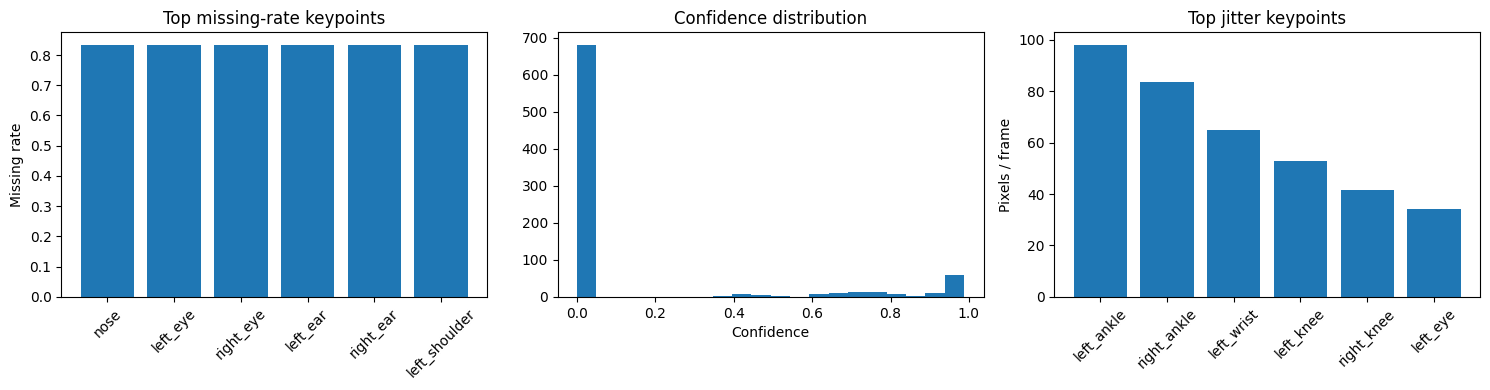

Saved /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/assets/generated/quality_metrics_overview.png


In [5]:
top_missing = sorted(missing_rate_per_keypoint.items(), key=lambda x: x[1], reverse=True)[:6]
top_jitter = sorted(jitter_per_keypoint.items(), key=lambda x: x[1], reverse=True)[:6]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar([k for k, _ in top_missing], [v for _, v in top_missing])
axes[0].set_title("Top missing-rate keypoints")
axes[0].set_ylabel("Missing rate")
axes[0].tick_params(axis="x", rotation=45)
axes[1].hist(df[confidence_cols].stack().dropna(), bins=20)
axes[1].set_title("Confidence distribution")
axes[1].set_xlabel("Confidence")
axes[2].bar([k for k, _ in top_jitter], [v for _, v in top_jitter])
axes[2].set_title("Top jitter keypoints")
axes[2].set_ylabel("Pixels / frame")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
figure_path = repo_root / "assets" / "generated" / "quality_metrics_overview.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=140)
plt.show()
print("Saved", figure_path)


In [6]:
quality_path = repo_root / "results" / "quality_metrics_summary.json"
with quality_path.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "summary": summary,
            "missing_rate_per_keypoint": missing_rate_per_keypoint,
            "jitter_per_keypoint": jitter_per_keypoint,
        },
        f,
        indent=2,
    )
    f.write("\n")
print("Saved", quality_path)
summary


Saved /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/quality_metrics_summary.json


{'rows': 48,
 'tool': 'mediapipe',
 'used_synthetic_fallback': False,
 'missing_rate_overall': 0.8333333333333333,
 'mean_confidence': 0.1358131543532306,
 'confidence_std': 0.31286915724994274,
 'mean_temporal_jitter_px': 37.13590345257923}

## Interpretation

- These metrics do not replace ground-truth evaluation.
- They are useful for screening data quality and temporal stability before model-level tasks.
- The exported JSON can feed monitoring dashboards or dataset QA checks.
